# 01 Data exploration

Signals, spectra and health trends of FEMTO, IMS and SCA. Values computed per recording are cached in `data/interim/` so later runs are fast.

### Setup, imports and signal helpers

In [1]:
import os
from pathlib import Path

if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import hilbert
from scipy.stats import kurtosis

from industrial_predictive_maintenance import datasets

INTERIM = Path("data/interim")
INTERIM.mkdir(parents=True, exist_ok=True)
CLIP_G = 48.1  # four FEMTO bearings peak at exactly 48.15 g

femto = datasets.femto_catalog()
ims_full = datasets.ims_catalog(documented_only=False)
sca = datasets.sca_catalog()
label_names = {-1: "off or no speed", 0: "normal", 1: "inner ring", 2: "ball", 3: "outer ring"}


def rms(x: np.ndarray) -> float:
    return float(np.sqrt(np.mean(np.square(x))))


def spectrum(x: np.ndarray, rate: float) -> tuple[np.ndarray, np.ndarray]:
    x = x - x.mean()
    return np.fft.rfftfreq(len(x), 1 / rate), np.abs(np.fft.rfft(x)) * 2 / len(x)


def envelope_spectrum(x: np.ndarray, rate: float) -> tuple[np.ndarray, np.ndarray]:
    return spectrum(np.abs(hilbert(x - x.mean())), rate)

# FEMTO raw signal section header

## FEMTO: raw signal and spectrum at the start and end of life

### FEMTO raw signals at the start and end of life

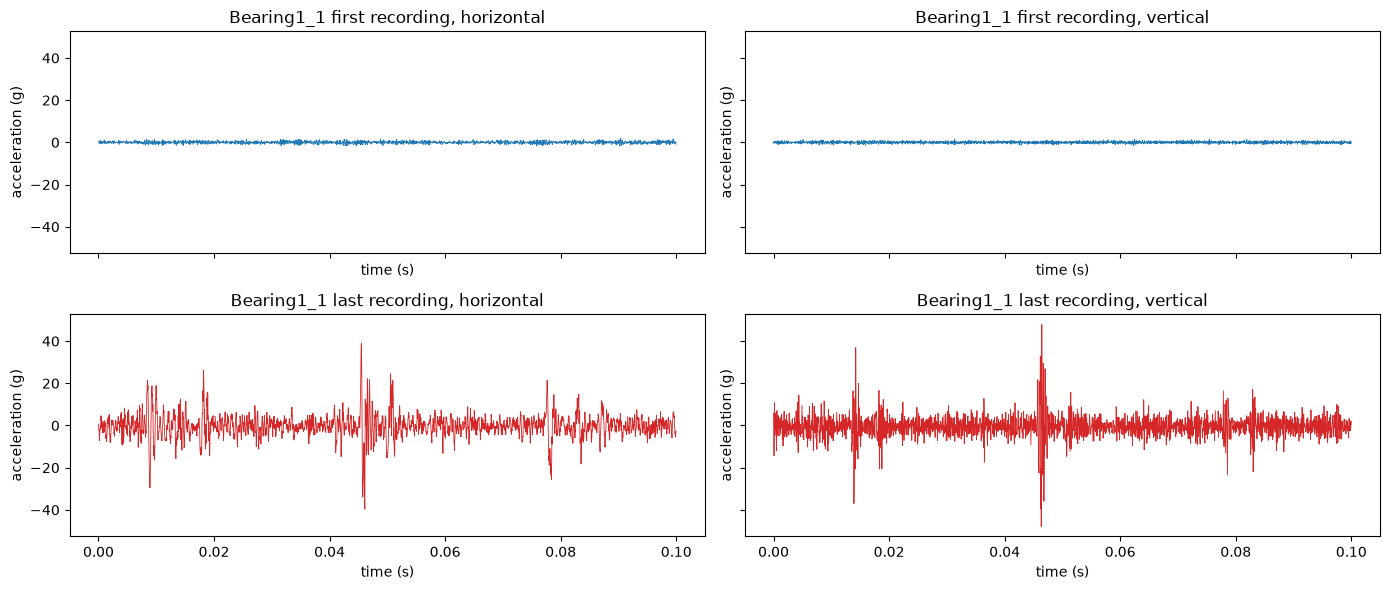

In [2]:
b = femto[femto["bearing"] == "Bearing1_1"]
first, last = datasets.read_femto(b["path"].iat[0]), datasets.read_femto(b["path"].iat[-1])
t = np.arange(len(first)) / datasets.FEMTO_SAMPLING_HZ

fig, axes = plt.subplots(2, 2, figsize=(14, 6), sharex=True, sharey=True)
for col, direction in enumerate(["horizontal", "vertical"]):
    axes[0, col].plot(t, first[:, col], lw=0.6)
    axes[0, col].set_title(f"Bearing1_1 first recording, {direction}")
    axes[1, col].plot(t, last[:, col], lw=0.6, color="tab:red")
    axes[1, col].set_title(f"Bearing1_1 last recording, {direction}")
for ax in axes.flat:
    ax.set_xlabel("time (s)")
    ax.set_ylabel("acceleration (g)")
plt.tight_layout()

### FEMTO spectrum at the start and end of life

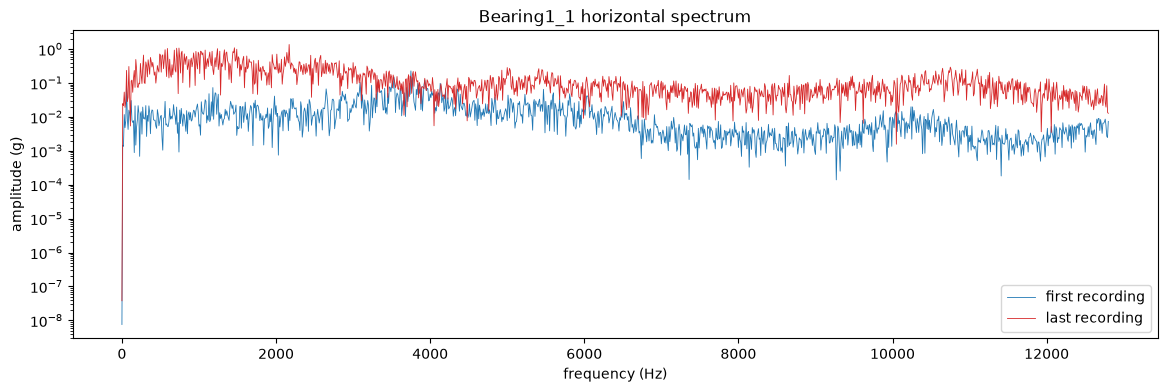

In [3]:
fig, ax = plt.subplots(figsize=(14, 4))
for x, name, color in ((first, "first recording", "tab:blue"), (last, "last recording", "tab:red")):
    f, a = spectrum(x[:, 0], datasets.FEMTO_SAMPLING_HZ)
    ax.plot(f, a, lw=0.6, label=name, color=color)
ax.set_yscale("log")
ax.set_xlabel("frequency (Hz)")
ax.set_ylabel("amplitude (g)")
ax.set_title("Bearing1_1 horizontal spectrum")
ax.legend()

# FEMTO health indicators section header

## FEMTO: health indicators for every recording

RMS, kurtosis and peak per recording, plus the number of samples at the 48.15 g limit. The first run reads all 24,889 files and takes a few minutes.

### FEMTO health indicators per recording

In [4]:
femto_trend_file = INTERIM / "femto_trends.parquet"
if femto_trend_file.exists():
    femto_trends = pd.read_parquet(femto_trend_file)
else:
    rows = []
    for row in femto.itertuples():
        x = datasets.read_femto(row.path)
        rows.append(
            {
                "bearing": row.bearing,
                "recording": row.recording,
                "rms_h": rms(x[:, 0]),
                "rms_v": rms(x[:, 1]),
                "kurtosis_h": float(kurtosis(x[:, 0], fisher=False)),
                "kurtosis_v": float(kurtosis(x[:, 1], fisher=False)),
                "peak_g": float(np.abs(x).max()),
                "samples_at_limit": int((np.abs(x) >= CLIP_G).sum()),
            }
        )
    femto_trends = pd.DataFrame(rows)
    femto_trends.to_parquet(femto_trend_file)

femto_trends = femto_trends.merge(
    femto[["bearing", "recording", "set", "condition", "seconds"]], on=["bearing", "recording"]
)
femto_trends["hours"] = femto_trends["seconds"] / 3600
femto_trends["life_fraction"] = femto_trends.groupby("bearing")["seconds"].transform(lambda s: s / s.max())
femto_trends.head()

,bearing,recording,rms_h,rms_v,kurtosis_h,kurtosis_v,peak_g,samples_at_limit,set,condition,seconds,hours,life_fraction
0,Bearing1_1,1,0.561746,0.435801,2.868535,2.964920,2.010,0,learning,1,0.0,0.000000,0.000000
1,Bearing1_1,2,0.535113,0.420968,2.915354,3.150620,1.915,0,learning,1,10.0,0.002778,0.000357
2,Bearing1_1,3,0.531158,0.425605,3.033388,2.938448,1.901,0,learning,1,20.0,0.005556,0.000714
3,Bearing1_1,4,0.554833,0.445524,3.043419,2.886681,1.910,0,learning,1,30.0,0.008333,0.001071
4,Bearing1_1,5,0.566652,0.423847,2.814523,2.965183,1.767,0,learning,1,40.0,0.011111,0.001428


### FEMTO RMS over time per condition

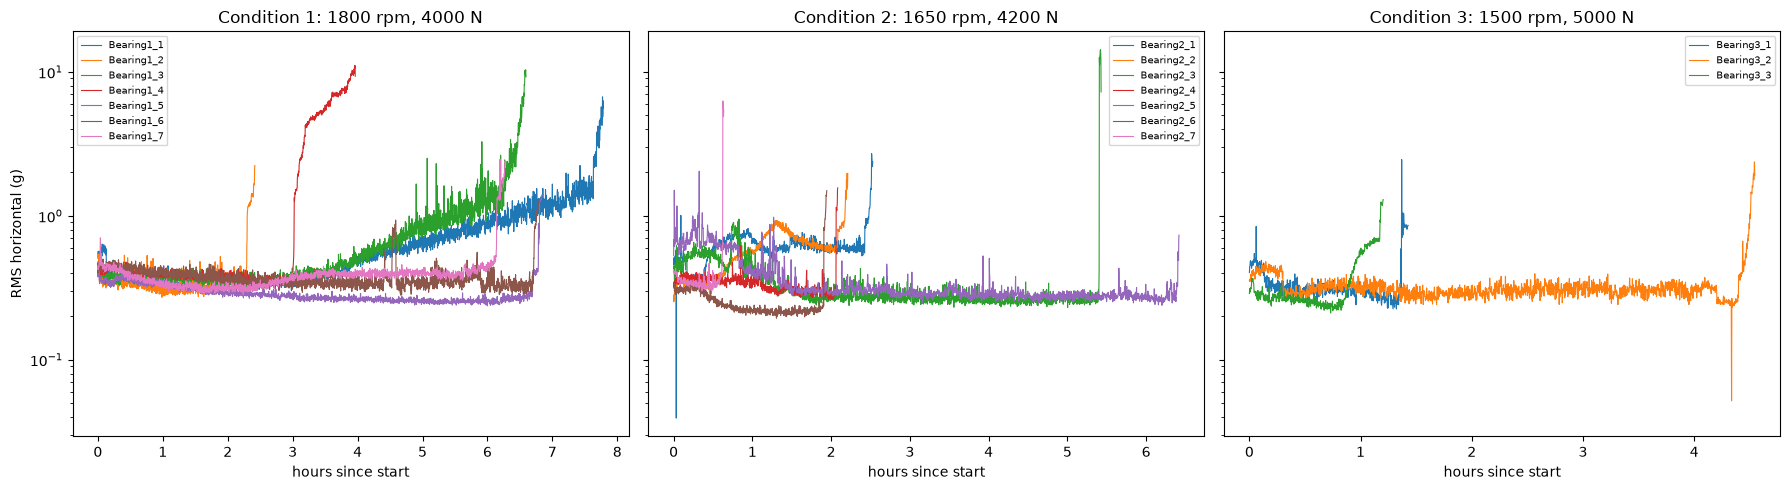

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, (condition, group) in zip(axes, femto_trends.groupby("condition")):
    for bearing, g in group.groupby("bearing"):
        ax.plot(g["hours"], g["rms_h"], lw=0.8, label=bearing)
    rpm, load_n = datasets.FEMTO_CONDITIONS[condition]
    ax.set_title(f"Condition {condition}: {rpm} rpm, {load_n} N")
    ax.set_xlabel("hours since start")
    ax.set_yscale("log")
    ax.legend(fontsize=7)
axes[0].set_ylabel("RMS horizontal (g)")
plt.tight_layout()

### FEMTO RMS and kurtosis over the fraction of life

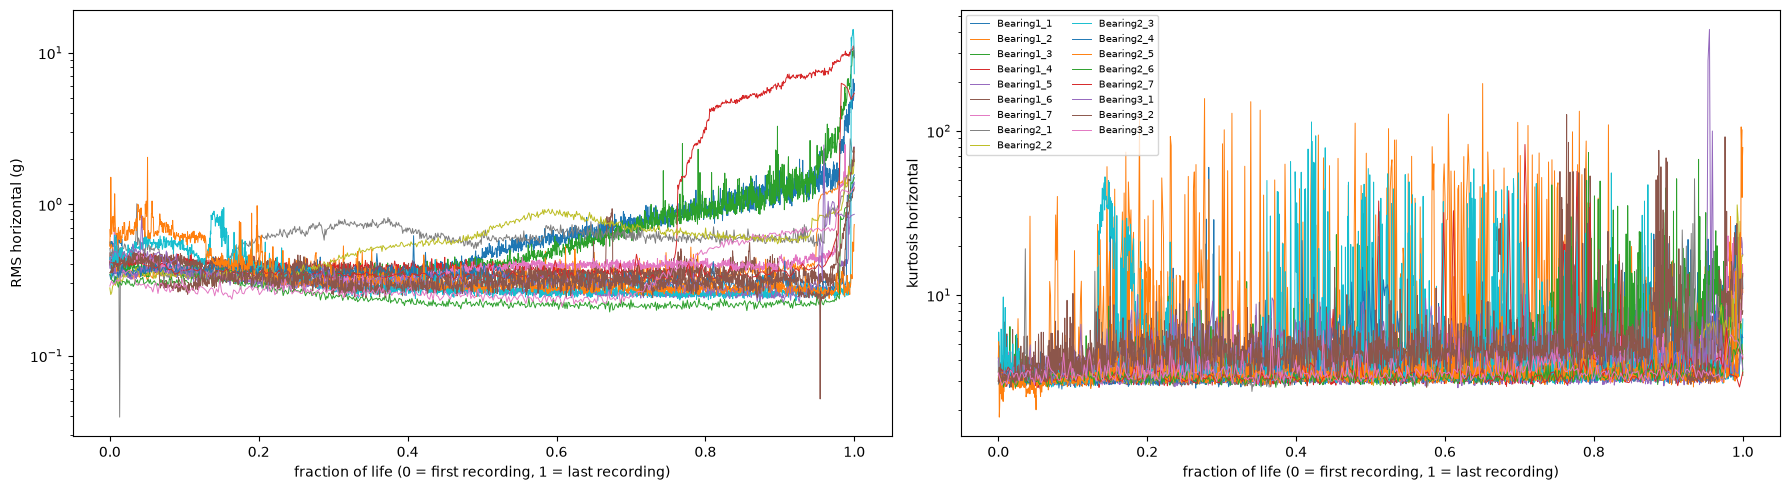

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
for ax, column, name in ((axes[0], "rms_h", "RMS horizontal (g)"), (axes[1], "kurtosis_h", "kurtosis horizontal")):
    for bearing, g in femto_trends.groupby("bearing"):
        ax.plot(g["life_fraction"], g[column], lw=0.7, label=bearing)
    ax.set_xlabel("fraction of life (0 = first recording, 1 = last recording)")
    ax.set_ylabel(name)
    ax.set_yscale("log")
axes[1].legend(fontsize=7, ncol=2)
plt.tight_layout()

### FEMTO peak per recording with the 20 g and 48.15 g lines

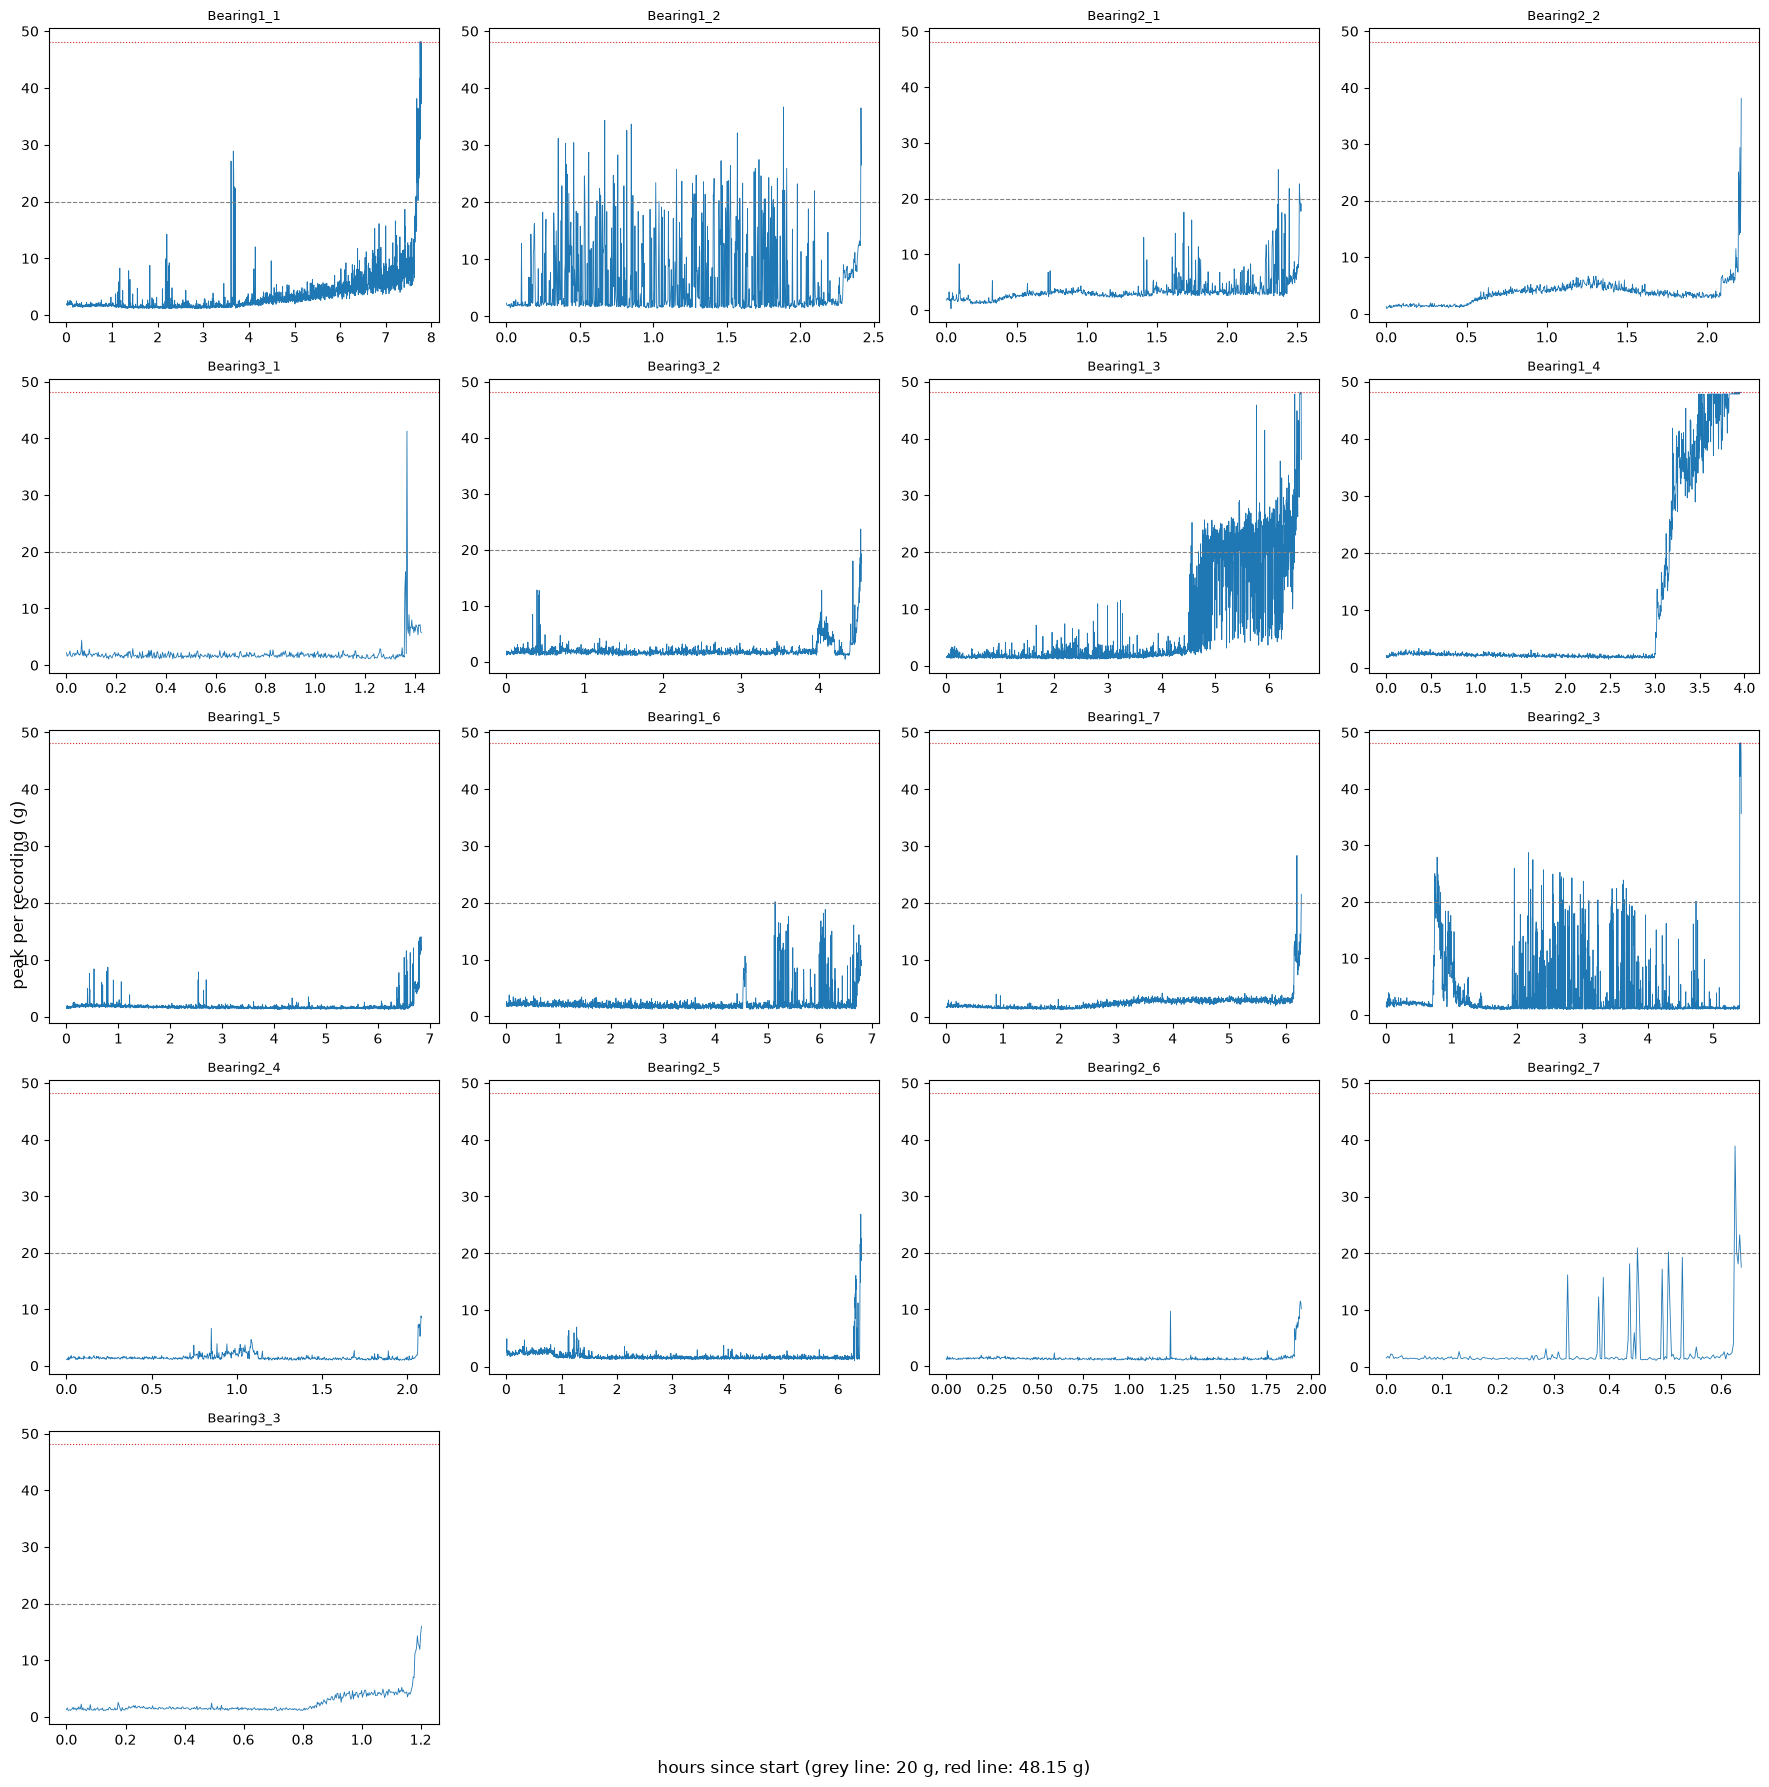

In [7]:
bearings = femto["bearing"].unique()
fig, axes = plt.subplots(5, 4, figsize=(18, 18))
for ax, bearing in zip(axes.flat, bearings):
    g = femto_trends[femto_trends["bearing"] == bearing]
    ax.plot(g["hours"], g["peak_g"], lw=0.6)
    ax.axhline(20, color="gray", ls="--", lw=0.8)
    ax.axhline(48.15, color="tab:red", ls=":", lw=0.8)
    ax.set_title(bearing, fontsize=9)
for ax in axes.flat[len(bearings):]:
    ax.axis("off")
fig.supxlabel("hours since start (grey line: 20 g, red line: 48.15 g)")
fig.supylabel("peak per recording (g)")
plt.tight_layout()

### FEMTO sensor limit summary

In [8]:
femto_trends.groupby("bearing", sort=False).agg(
    max_peak_g=("peak_g", "max"),
    recordings_at_limit=("samples_at_limit", lambda s: int((s > 0).sum())),
    samples_at_limit=("samples_at_limit", "sum"),
    hours=("hours", "max"),
).round(2)

,max_peak_g,recordings_at_limit,samples_at_limit,hours
bearing,,,,
Bearing1_1,48.15,2,6,7.78
Bearing1_2,36.72,0,0,2.42
Bearing2_1,25.19,0,0,2.53
Bearing2_2,38.12,0,0,2.21
Bearing3_1,41.30,0,0,1.43
Bearing3_2,23.72,0,0,4.54
Bearing1_3,48.15,7,25,6.59
Bearing1_4,48.15,17,24,3.96
Bearing1_5,14.05,0,0,6.84


### FEMTO lifetimes

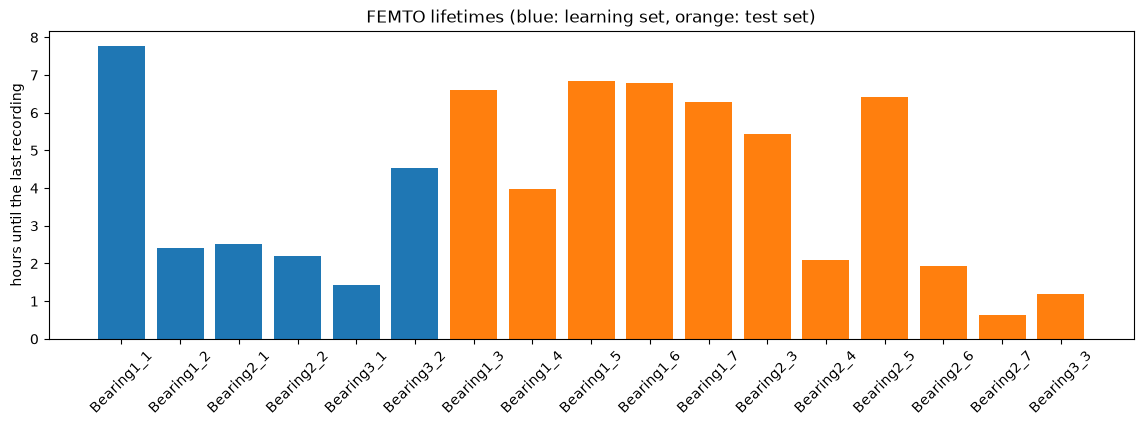

In [9]:
lifetimes = femto_trends.groupby("bearing", sort=False).agg(hours=("hours", "max"), set=("set", "first"))
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(lifetimes.index, lifetimes["hours"], color=lifetimes["set"].map({"learning": "tab:blue", "test": "tab:orange"}))
ax.set_ylabel("hours until the last recording")
ax.set_title("FEMTO lifetimes (blue: learning set, orange: test set)")
ax.tick_params(axis="x", labelrotation=45)

### FEMTO temperature

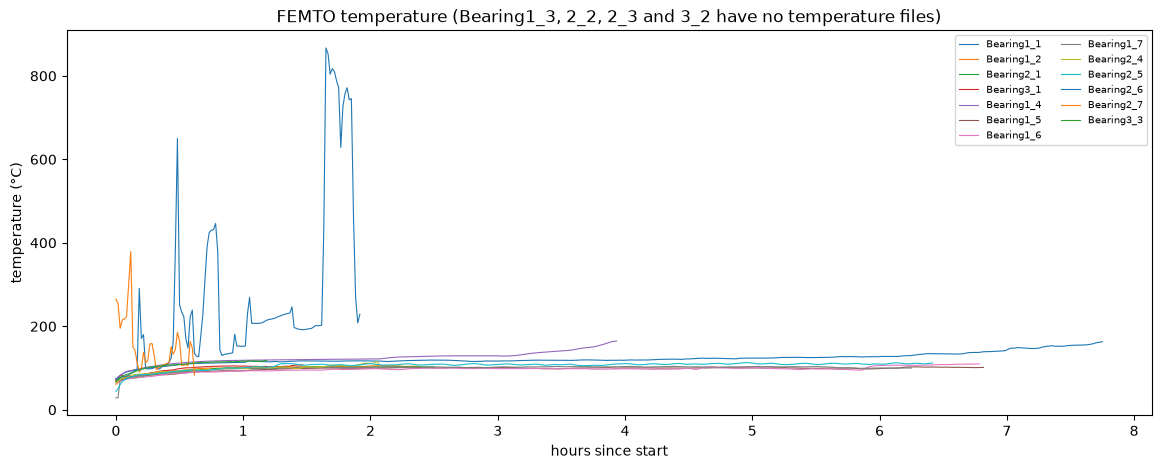

In [10]:
def femto_temperature(bearing: str) -> pd.Series:
    """Mean temperature of each temp_ file. Each file covers about one minute."""
    folder = Path(femto.loc[femto["bearing"] == bearing, "path"].iat[0]).parent
    values = []
    for f in sorted(folder.glob("temp_*.csv")):
        with f.open() as handle:
            sep = ";" if ";" in handle.readline() else ","
        values.append(pd.read_csv(f, header=None, sep=sep)[4].mean())
    return pd.Series(values, dtype=float)


fig, ax = plt.subplots(figsize=(14, 5))
for bearing in bearings:
    temperature = femto_temperature(bearing)
    if len(temperature):
        ax.plot(np.arange(len(temperature)) / 60, temperature, lw=0.8, label=bearing)
ax.set_xlabel("hours since start")
ax.set_ylabel("temperature (°C)")
ax.set_title("FEMTO temperature (Bearing1_3, 2_2, 2_3 and 3_2 have no temperature files)")
ax.legend(fontsize=7, ncol=2)

# IMS section header

## IMS: health indicators over the whole archive

The first run reads all 9,464 files and takes several minutes. Test 3 is shown up to the end of the archive, with the documented end marked.

### IMS health indicators per recording

In [11]:
ims_trend_file = INTERIM / "ims_trends.parquet"
if ims_trend_file.exists():
    ims_trends = pd.read_parquet(ims_trend_file)
else:
    rows = []
    for row in ims_full.itertuples():
        x = datasets.read_ims(row.path)
        values = {"test": row.test, "time": row.time}
        for ch in range(x.shape[1]):
            values[f"rms_ch{ch + 1}"] = rms(x[:, ch])
            values[f"kurtosis_ch{ch + 1}"] = float(kurtosis(x[:, ch], fisher=False))
        rows.append(values)
    ims_trends = pd.DataFrame(rows)
    ims_trends.to_parquet(ims_trend_file)
ims_trends.head()

,test,time,rms_ch1,kurtosis_ch1,rms_ch2,kurtosis_ch2,rms_ch3,kurtosis_ch3,rms_ch4,kurtosis_ch4,rms_ch5,kurtosis_ch5,rms_ch6,kurtosis_ch6,rms_ch7,kurtosis_ch7,rms_ch8,kurtosis_ch8
0,1,2003-10-22 12:06:24,0.124614,4.069163,0.117493,6.065884,0.130455,3.209486,0.121642,3.292221,0.128887,3.405438,0.131821,3.777063,0.109020,3.790249,0.115267,4.807989
1,1,2003-10-22 12:09:13,0.123811,4.161551,0.116833,5.001015,0.131490,3.229384,0.122182,3.291645,0.129562,3.445718,0.132049,3.682277,0.108900,4.234702,0.109208,4.873189
2,1,2003-10-22 12:14:13,0.125246,3.986286,0.118384,4.968952,0.131906,3.208701,0.123572,3.173296,0.131339,3.389712,0.133300,3.750422,0.110319,3.924709,0.113696,4.429695
3,1,2003-10-22 12:19:13,0.125197,4.034294,0.119005,4.745370,0.131614,3.189024,0.122750,3.319831,0.131083,3.261962,0.133969,3.667213,0.111037,3.652668,0.114413,4.378184
4,1,2003-10-22 12:24:13,0.125618,4.110163,0.119688,4.181160,0.130779,3.260858,0.121866,3.340824,0.131307,3.326192,0.133281,3.475304,0.110190,3.635575,0.114258,4.497653


### IMS RMS per bearing

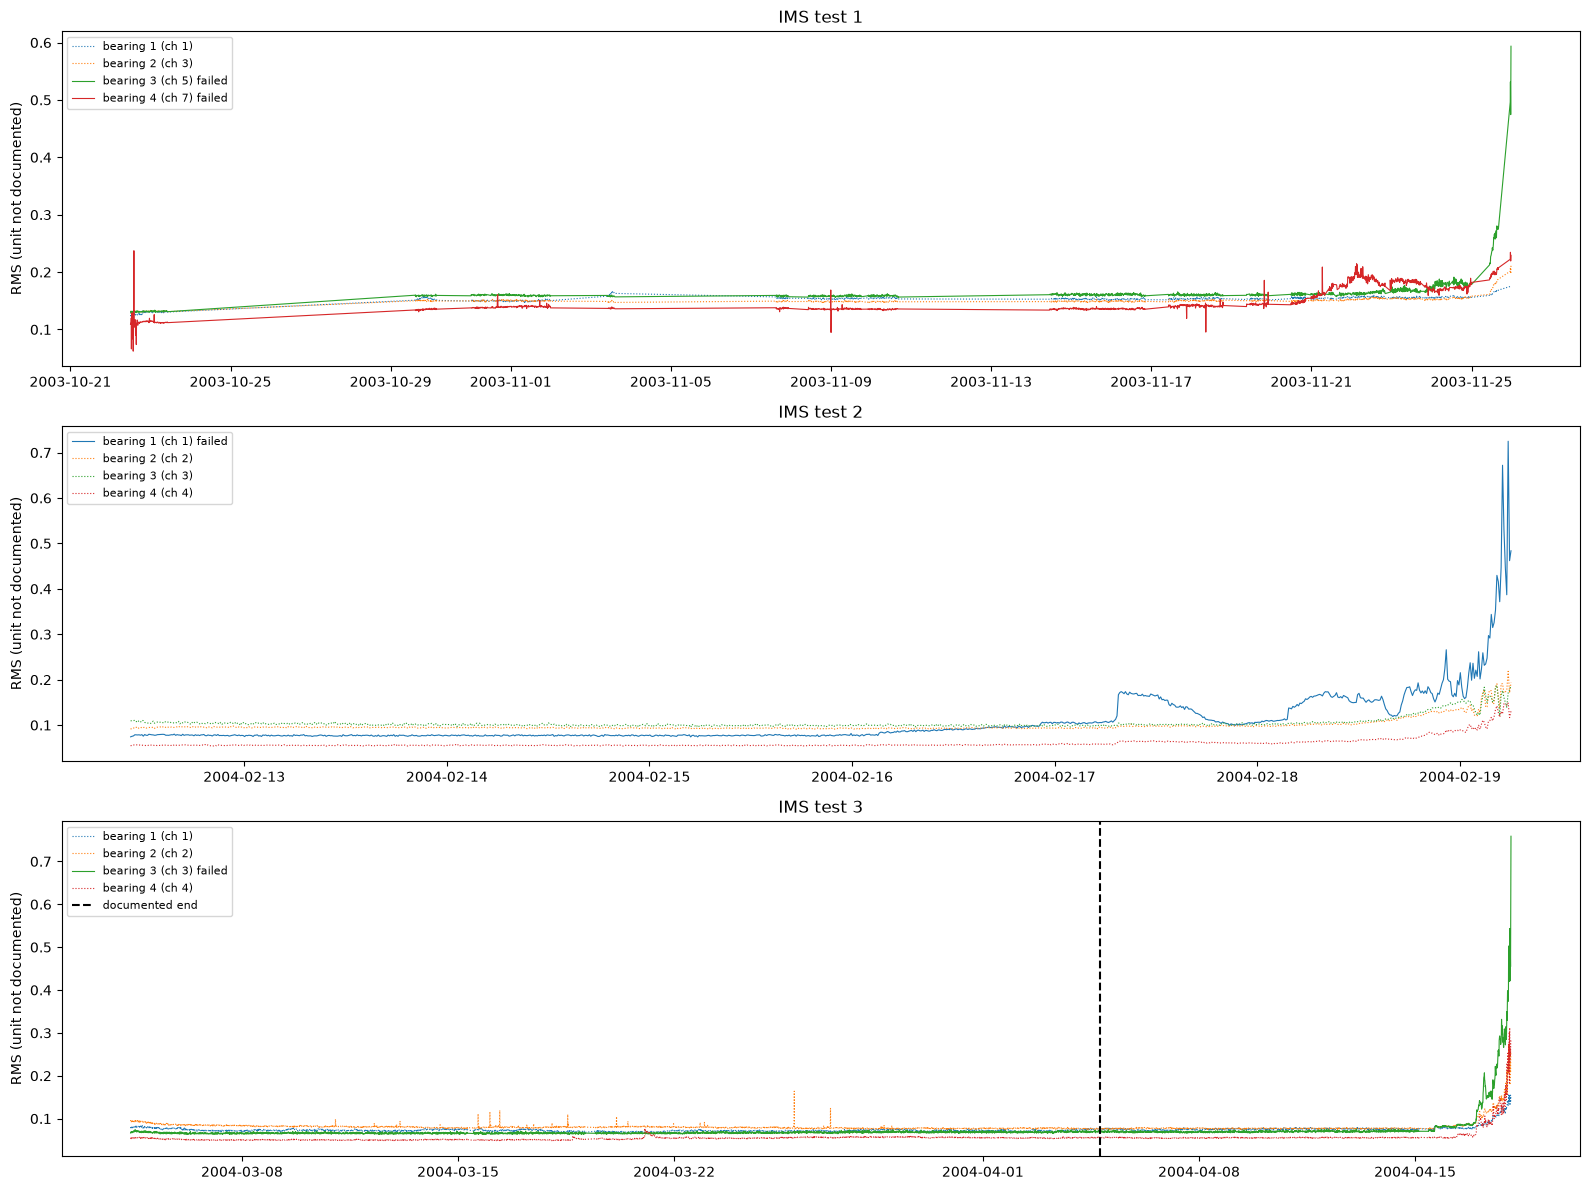

In [12]:
# Test 1 has two channels per bearing. The first channel of each bearing is shown.
bearing_channels = {1: [1, 3, 5, 7], 2: [1, 2, 3, 4], 3: [1, 2, 3, 4]}
failed = {1: [3, 4], 2: [1], 3: [3]}


def plot_ims(metric: str, label: str) -> None:
    fig, axes = plt.subplots(3, 1, figsize=(16, 12))
    for ax, test in zip(axes, (1, 2, 3)):
        g = ims_trends[ims_trends["test"] == test]
        for bearing, ch in enumerate(bearing_channels[test], start=1):
            is_failed = bearing in failed[test]
            ax.plot(
                g["time"], g[f"{metric}_ch{ch}"], "-" if is_failed else ":", lw=0.8,
                label=f"bearing {bearing} (ch {ch})" + (" failed" if is_failed else ""),
            )
        if test == 3:
            ax.axvline(datasets.IMS_TEST3_DOCUMENTED_END, color="black", ls="--", label="documented end")
        ax.set_title(f"IMS test {test}")
        ax.set_ylabel(label)
        ax.legend(fontsize=8)
    plt.tight_layout()


plot_ims("rms", "RMS (unit not documented)")

### IMS kurtosis per bearing

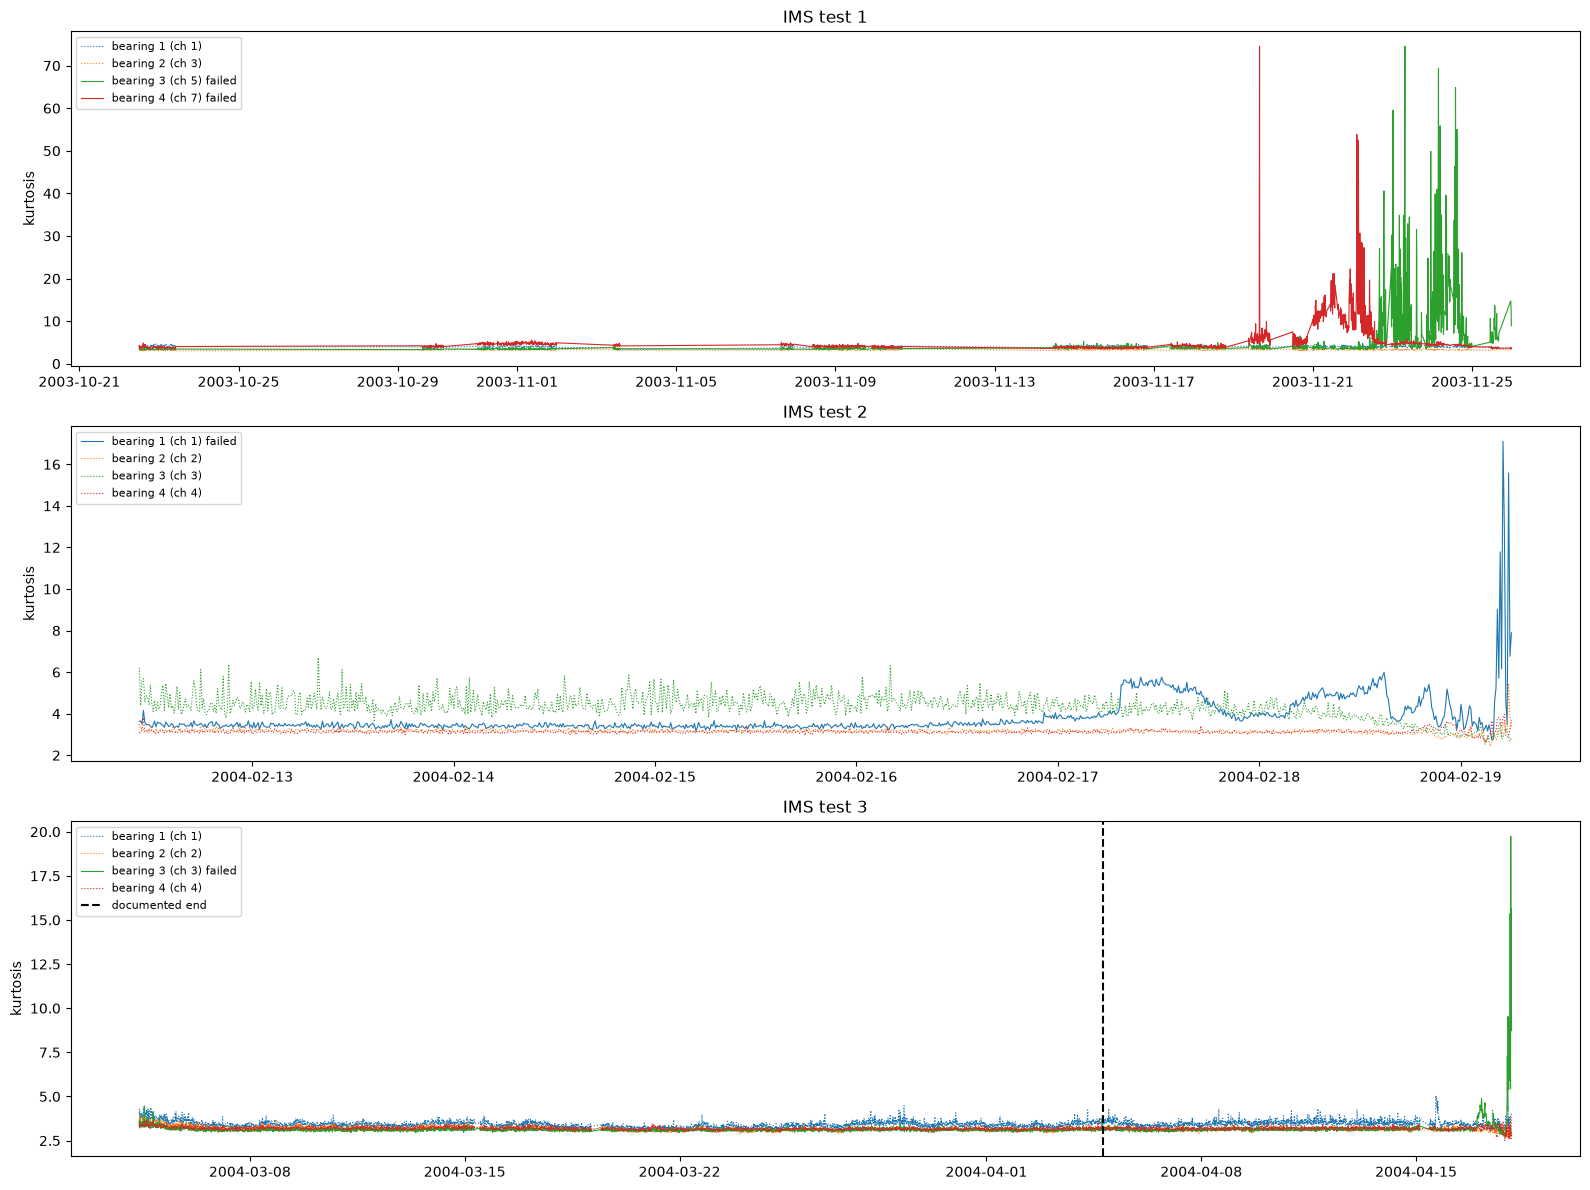

In [13]:
plot_ims("kurtosis", "kurtosis")

### IMS failed bearing signal and envelope spectrum

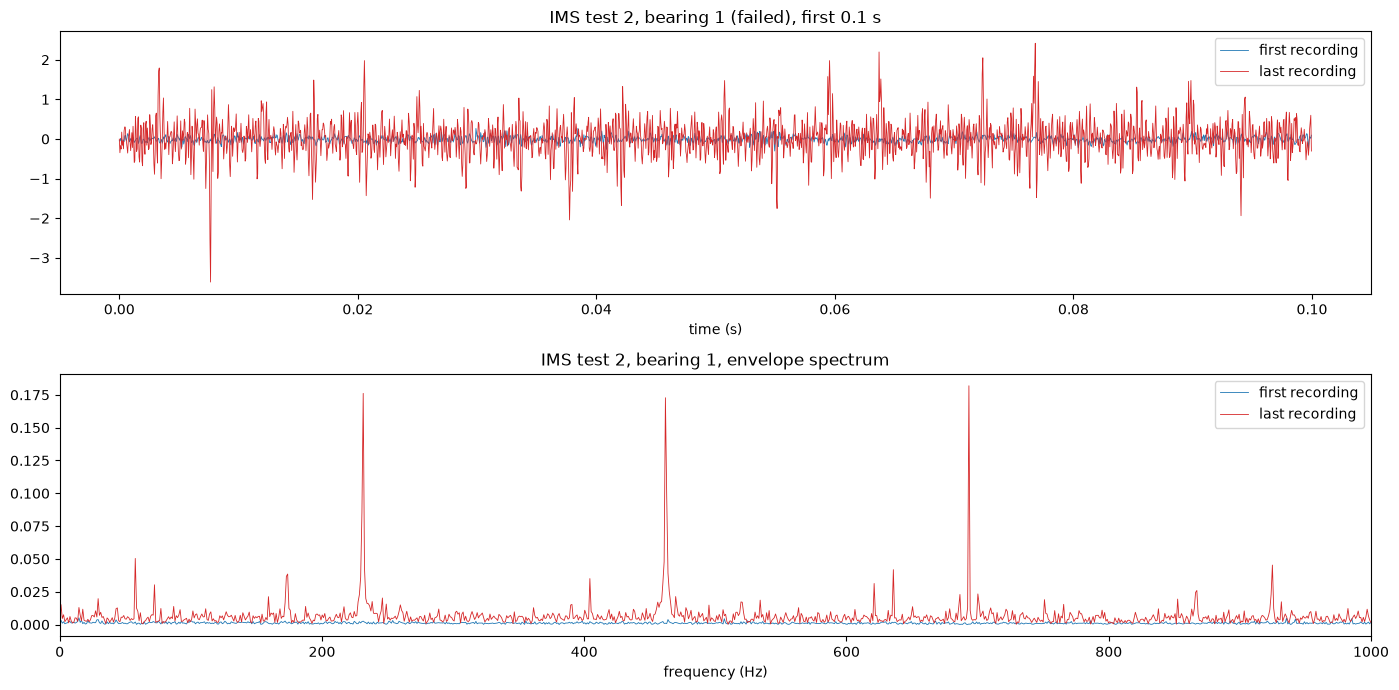

In [14]:
test2 = ims_full[ims_full["test"] == 2]
first2, last2 = datasets.read_ims(test2["path"].iat[0]), datasets.read_ims(test2["path"].iat[-1])

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
t = np.arange(2000) / datasets.IMS_SAMPLING_HZ
axes[0].plot(t, first2[:2000, 0], lw=0.6, label="first recording")
axes[0].plot(t, last2[:2000, 0], lw=0.6, color="tab:red", label="last recording")
axes[0].set_title("IMS test 2, bearing 1 (failed), first 0.1 s")
axes[0].set_xlabel("time (s)")
axes[0].legend()
for x, name, color in ((first2, "first recording", "tab:blue"), (last2, "last recording", "tab:red")):
    f, a = envelope_spectrum(x[:, 0], datasets.IMS_SAMPLING_HZ)
    axes[1].plot(f, a, lw=0.6, label=name, color=color)
axes[1].set_xlim(0, 1000)
axes[1].set_title("IMS test 2, bearing 1, envelope spectrum")
axes[1].set_xlabel("frequency (Hz)")
axes[1].legend()
plt.tight_layout()

# SCA section header

## SCA: fault development in the pulp mill

RMS, kurtosis and peak for all 6,644 measurements. Only the placement where the fault occurred is shown in the per-case plots.

### SCA health indicators per measurement

In [15]:
sca_trend_file = INTERIM / "sca_trends.parquet"
if sca_trend_file.exists():
    sca_trends = pd.read_parquet(sca_trend_file)
else:
    rows = []
    for row in sca.itertuples():
        x = datasets.read_sca(row.case, row.part, row.placement, row.measurement)
        rows.append(
            {
                "case": row.case,
                "part": row.part,
                "placement": row.placement,
                "measurement": row.measurement,
                "rms": rms(x),
                "kurtosis": float(kurtosis(x, fisher=False)),
                "peak": float(np.abs(x).max()),
            }
        )
    sca_trends = pd.DataFrame(rows)
    sca_trends.to_parquet(sca_trend_file)

sca_trends = sca_trends.merge(sca, on=["case", "part", "placement", "measurement"])
sca_trends.head()

,case,part,placement,measurement,rms,kurtosis,peak,time,sampling_hz,rpm,label,bearing,asset,fault_origin
0,1,train,DS,0,0.067002,2.813530,0.253394,2022-05-13 15:01:07.170,640.0,1086.877690,0,SKF22320 E,Roller,DS
1,1,train,DS,1,0.057676,2.927126,0.224519,2022-05-14 14:00:48.160,640.0,1029.692140,0,SKF22320 E,Roller,DS
2,1,train,DS,2,0.042970,3.015640,0.176787,2022-05-15 13:00:22.590,640.0,971.594238,0,SKF22320 E,Roller,DS
3,1,train,DS,3,0.067109,2.862563,0.242198,2022-05-16 12:00:23.690,640.0,1058.021850,0,SKF22320 E,Roller,DS
4,1,train,DS,4,0.065762,2.962334,0.276376,2022-05-17 11:00:35.280,640.0,1057.952510,0,SKF22320 E,Roller,DS


### SCA RMS by label per case

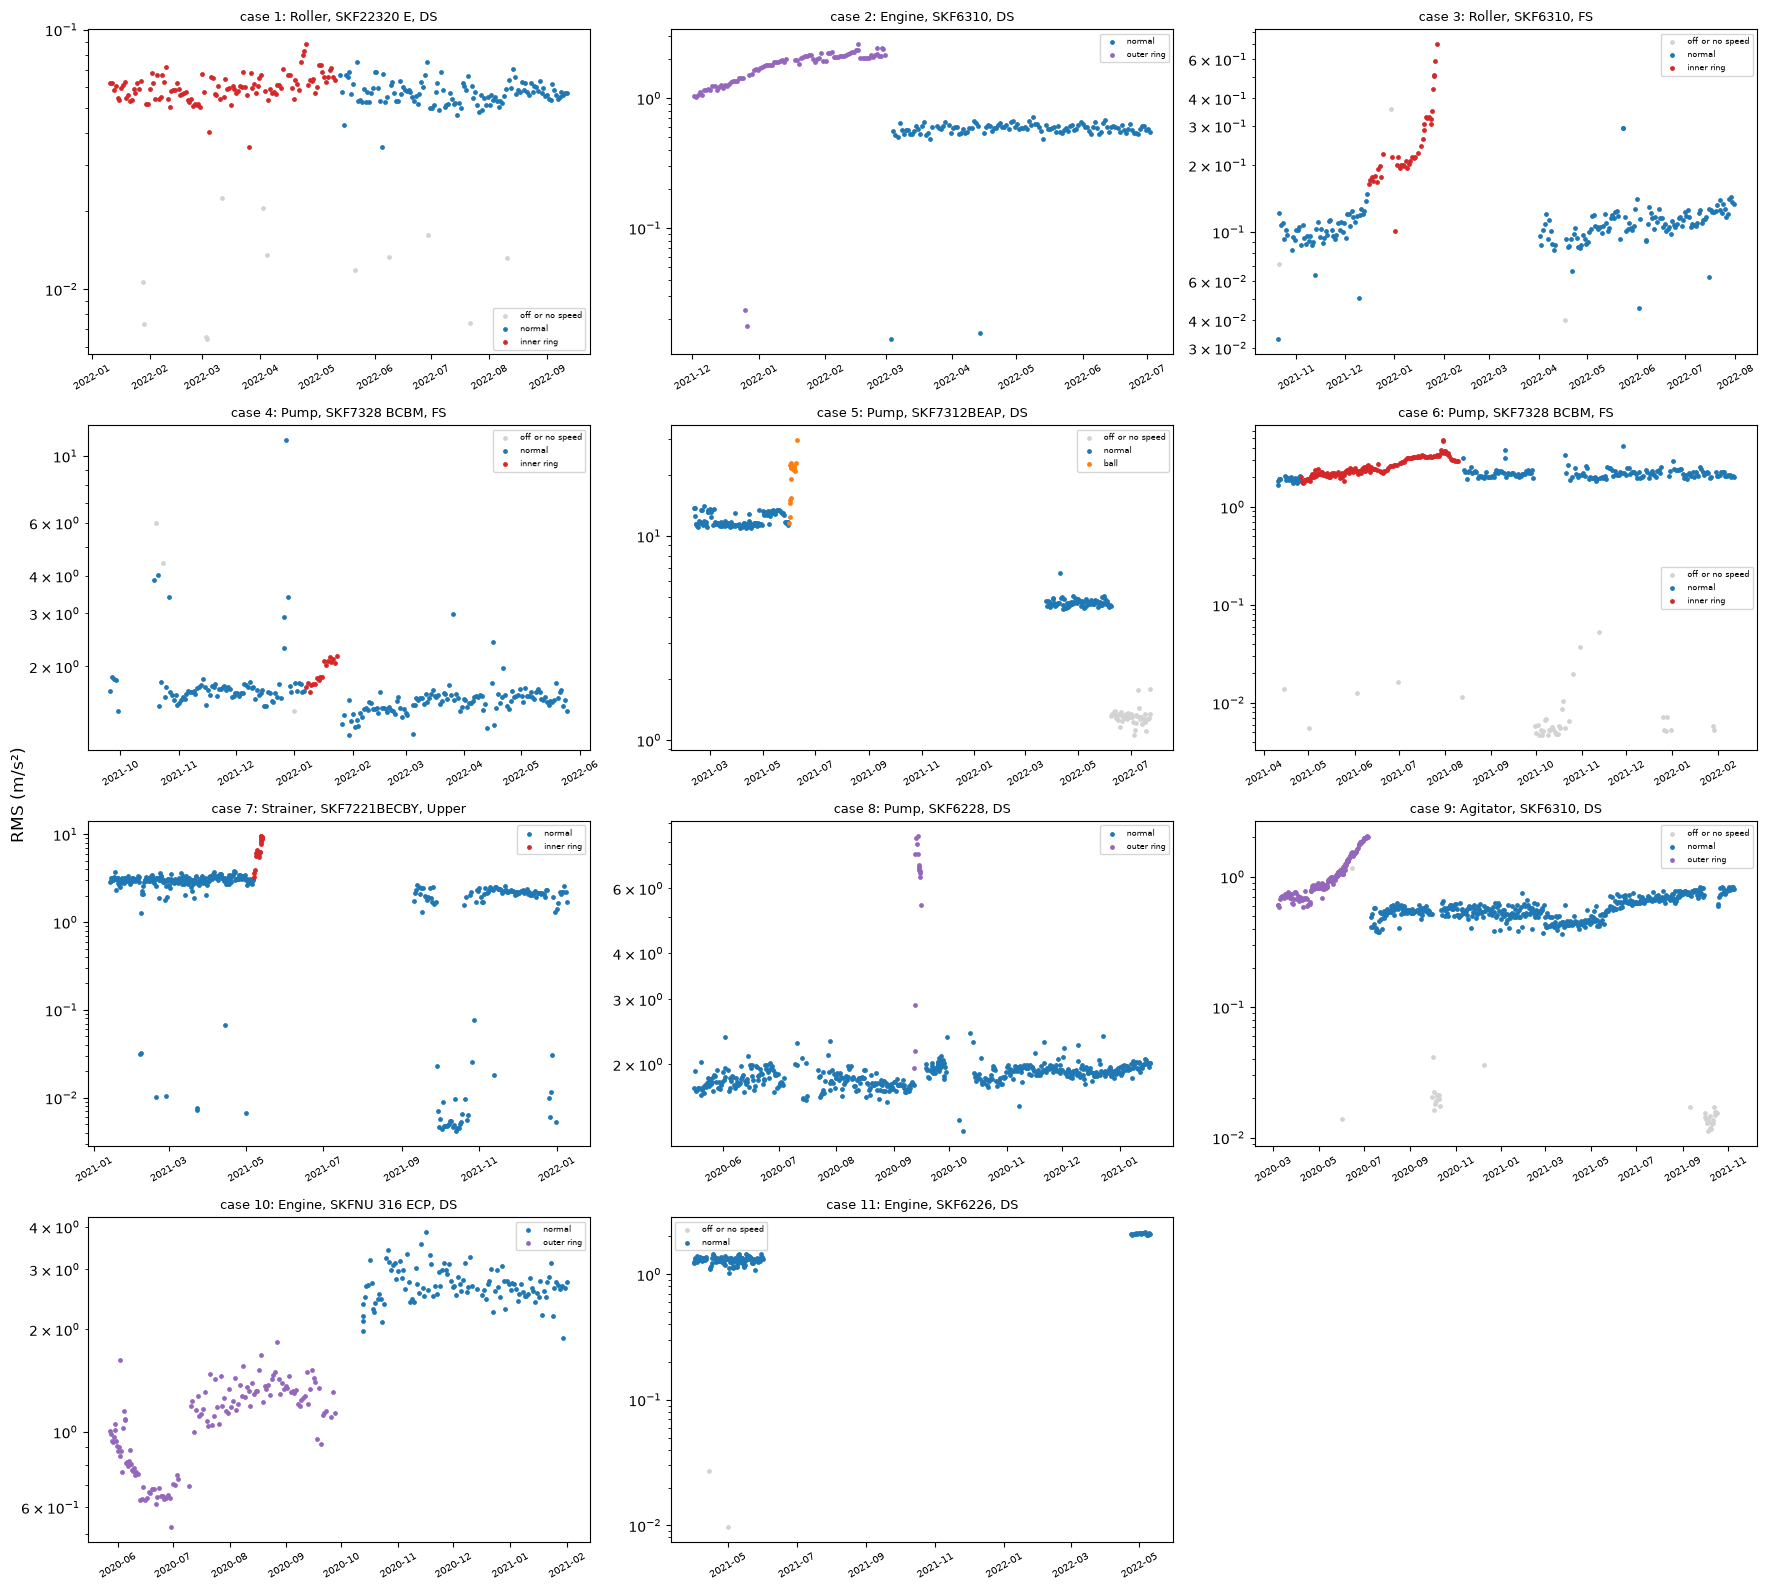

In [16]:
colors = {-1: "lightgray", 0: "tab:blue", 1: "tab:red", 2: "tab:orange", 3: "tab:purple"}
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
for ax, (case, g) in zip(axes.flat, sca_trends.groupby("case")):
    origin = g[g["placement"].str.lower() == g["fault_origin"].str.lower()]
    g = origin if len(origin) else g
    for label, gl in g.groupby("label"):
        ax.scatter(gl["time"], gl["rms"], s=6, color=colors[label], label=label_names[label])
    ax.set_title(f"case {case}: {g['asset'].iat[0]}, {g['bearing'].iat[0]}, {g['placement'].iat[0]}", fontsize=9)
    ax.set_yscale("log")
    ax.tick_params(axis="x", labelrotation=30, labelsize=7)
    ax.legend(fontsize=6)
axes.flat[-1].axis("off")
fig.supylabel("RMS (m/s²)")
plt.tight_layout()

### SCA shaft speed per case

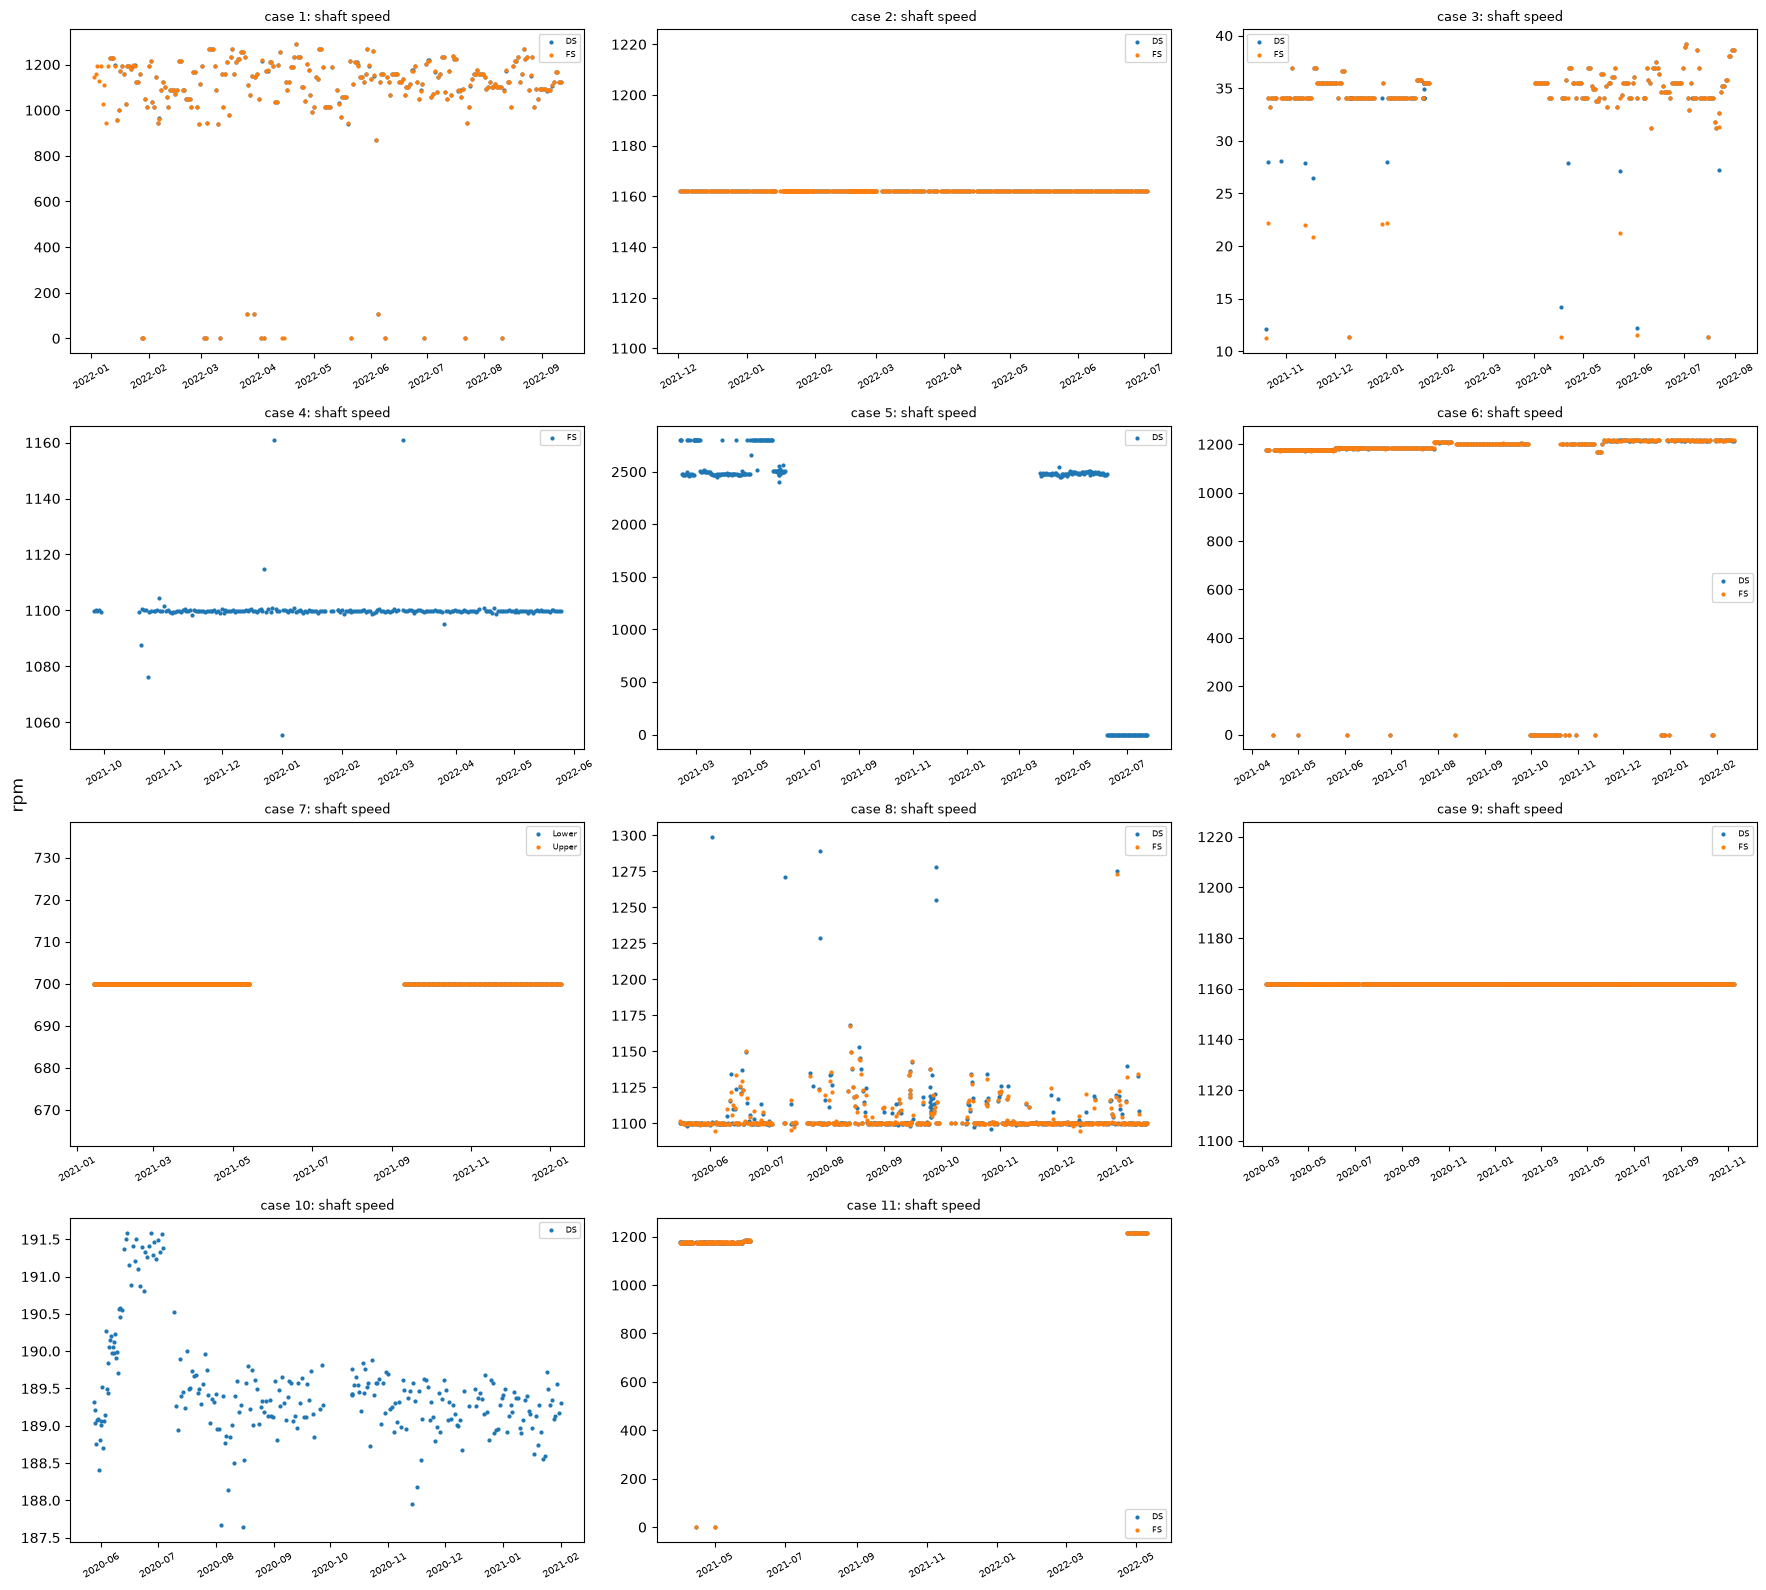

In [17]:
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
for ax, (case, g) in zip(axes.flat, sca.groupby("case")):
    for placement, gp in g.groupby("placement"):
        ax.scatter(gp["time"], gp["rpm"], s=4, label=placement)
    ax.set_title(f"case {case}: shaft speed", fontsize=9)
    ax.tick_params(axis="x", labelrotation=30, labelsize=7)
    ax.legend(fontsize=6)
axes.flat[-1].axis("off")
fig.supylabel("rpm")
plt.tight_layout()

### SCA envelope spectrum with fault frequencies, case 8

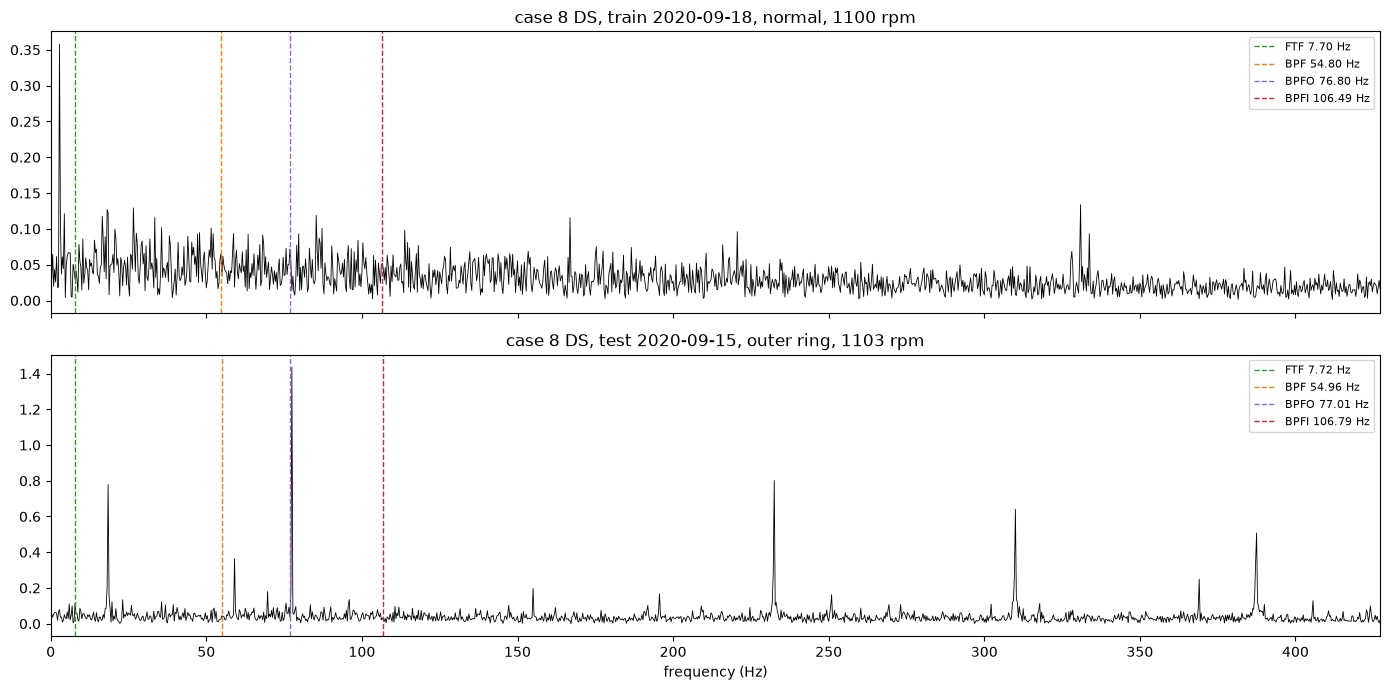

In [18]:
def plot_envelope(case: int, placement: str, harmonics: int = 4) -> None:
    """Envelope spectrum of a normal and a faulty measurement with the bearing fault frequencies."""
    orders = datasets.sca_fault_orders(case, "test", placement)
    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
    for ax, part, position in ((axes[0], "train", 0), (axes[1], "test", -1)):
        rows = sca[(sca["case"] == case) & (sca["part"] == part) & (sca["placement"] == placement) & (sca["rpm"] > 0)]
        row = rows.iloc[position]
        x = datasets.read_sca(case, part, placement, int(row["measurement"]))
        f, a = envelope_spectrum(x, row["sampling_hz"])
        shaft_hz = row["rpm"] / 60
        ax.plot(f, a, lw=0.6, color="black")
        for (name, order), color in zip(orders.items(), ["tab:green", "tab:orange", "tab:purple", "tab:red"]):
            ax.axvline(order * shaft_hz, color=color, ls="--", lw=1, label=f"{name} {order * shaft_hz:.2f} Hz")
        ax.set_xlim(0, harmonics * max(orders.values()) * shaft_hz)
        ax.set_title(
            f"case {case} {placement}, {part} {row['time']:%Y-%m-%d}, "
            f"{label_names[row['label']]}, {row['rpm']:.0f} rpm"
        )
        ax.legend(fontsize=8)
    axes[1].set_xlabel("frequency (Hz)")
    plt.tight_layout()


plot_envelope(8, "DS")

### SCA fault frequency check, case 1

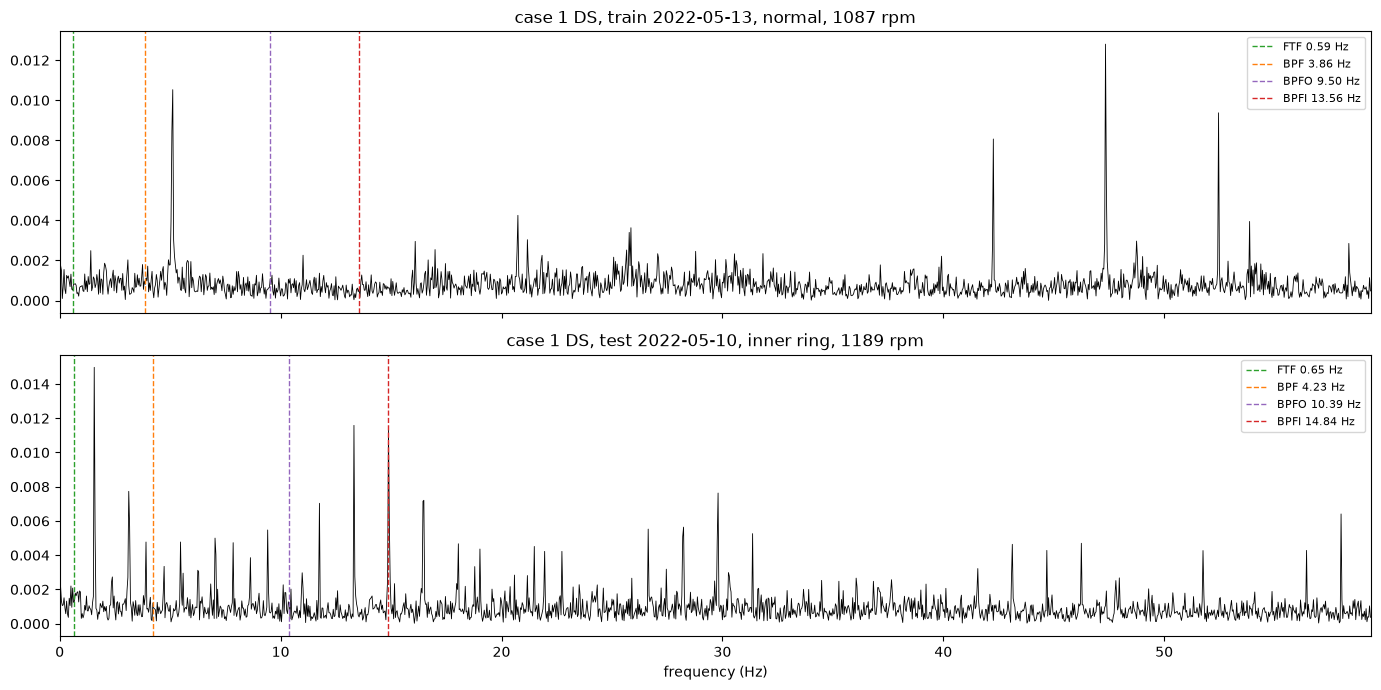

In [19]:
# Case 1 has fault frequency multiples below 1. Check whether its peaks line up with them.
plot_envelope(1, "DS")

### SCA case 11 external event

Text(0.5, 1.0, 'SCA case 11: external event in test, labelled normal')

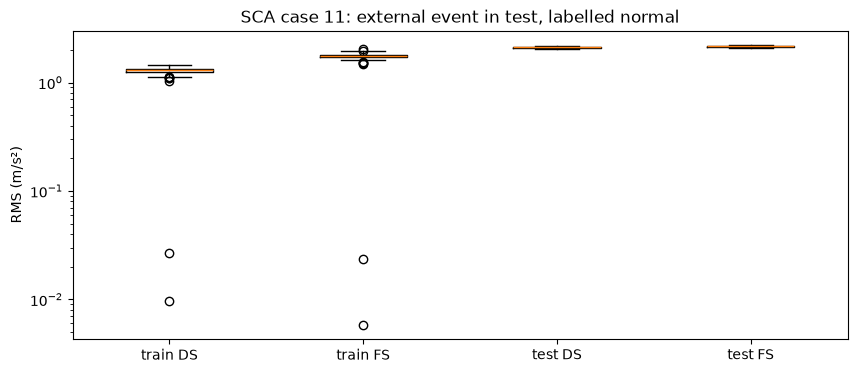

In [20]:
case11 = sca_trends[sca_trends["case"] == 11]
fig, ax = plt.subplots(figsize=(10, 4))
data = [case11.loc[(case11["part"] == part) & (case11["placement"] == p), "rms"] for part in ("train", "test") for p in ("DS", "FS")]
ax.boxplot(data, tick_labels=["train DS", "train FS", "test DS", "test FS"])
ax.set_yscale("log")
ax.set_ylabel("RMS (m/s²)")
ax.set_title("SCA case 11: external event in test, labelled normal")

# Questions to answer from the plots

## Questions to answer from these plots

- FEMTO: when does RMS start to rise for each bearing, and how sudden is it?
- FEMTO: which bearings reach the 48.15 g limit, and for how many recordings?
- FEMTO: does temperature rise before the end of life?
- IMS: do the failed bearings show a clear trend before the end?
- IMS test 3: does bearing 3 change before the documented end, after it or not at all?
- SCA: how early does each fault show in RMS, and are there jumps caused by speed changes?
- SCA case 1: do the peaks match the fault frequencies, or are the stored multiples wrong?
- SCA case 11: how far does the external event move RMS away from normal?